## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Oct 31 06:32:45 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   61C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install FastSAM, SAM, and other dependencies

In [3]:
%cd {HOME}

# install FastSAM
!git clone https://github.com/CASIA-IVA-Lab/FastSAM.git
!pip -q install -r FastSAM/requirements.txt
# install CLIP
!pip -q install git+https://github.com/openai/CLIP.git
# install other dependencies
!pip -q install roboflow supervision jupyter_bbox_widget

/content
Cloning into 'FastSAM'...
remote: Enumerating objects: 1329, done.
remote: Counting objects: 100% (401/401), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 1329 (delta 346), reused 307 (delta 307), pack-reused 928 (from 1)
Receiving objects: 100% (1329/1329), 72.56 MiB | 29.27 MiB/s, done.
Resolving deltas: 100% (542/542), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.8/319.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 6.5 MB/s eta 0:00:00
  Prepar

## Download FastSAM and SAM weights

In [4]:
!mkdir -p {HOME}/weights
!wget -P {HOME}/weights -q https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM.pt
!ls -lh {HOME}/weights

total 139M
-rw-r--r-- 1 root root 139M Jun 20  2023 FastSAM.pt


In [5]:
FAST_SAM_CHECKPOINT_PATH = f"{HOME}/weights/FastSAM.pt"

In [6]:
%cd {HOME}/FastSAM

import os
import cv2
import torch
import roboflow
import base64

import supervision as sv
import numpy as np

from roboflow import Roboflow
from fastsam import FastSAM, FastSAMPrompt
# from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

/content/FastSAM


## Load FastSAM

In [7]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"DEVICE = {DEVICE}")
fast_sam = FastSAM(FAST_SAM_CHECKPOINT_PATH)

DEVICE = cuda:0


## FastSAM inference

* `retina_masks=True` determines whether the model uses retina masks for generating segmentation masks.
* `imgsz=1024` sets the input image size to 1024x1024 pixels for processing by the model.
* `conf=0.4` sets the minimum confidence threshold for object detection.
* `iou=0.9` sets the minimum intersection over union threshold for non-maximum suppression to filter out duplicate detections.

In [11]:
# Convert masks to boolean (True/False)
def masks_to_bool(masks):
    if type(masks) == np.ndarray:
        return masks.astype(bool)
    return masks.cpu().numpy().astype(bool)

In [12]:
def annotate_image(image_path: str, masks: np.ndarray) -> np.ndarray:
    image = cv2.imread(image_path)

    xyxy = sv.mask_to_xyxy(masks=masks)
    detections = sv.Detections(xyxy=xyxy, mask=masks)

    mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)
    return mask_annotator.annotate(scene=image.copy(), detections=detections)

**NOTE:** The quality of the generated masks is quite poor. Let's see if we can improve it by manipulating the parameters.

### FastSAM inference

In [21]:
# Load the image
IMAGE_PATH = '/content/1.png'
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [22]:
results = fast_sam(
    source=IMAGE_PATH,
    device=DEVICE,
    retina_masks=True,
    imgsz=1024,
    conf=0.5,
    iou=0.6)
prompt_process = FastSAMPrompt(IMAGE_PATH, results, device=DEVICE)
masks = prompt_process.everything_prompt()
masks = masks_to_bool(masks)
xyxy = sv.mask_to_xyxy(masks=masks)
fast_sam_detections = sv.Detections(xyxy=xyxy, mask=masks)


image 1/1 /content/1.png: 736x1024 49 objects, 137.9ms
Speed: 4.3ms preprocess, 137.9ms inference, 7.0ms postprocess per image at shape (1, 3, 1024, 1024)


In [24]:
fast_sam_detections.xyxy[:4]

array([[ 81,  83, 186, 188],
       [191, 193, 297, 299],
       [340,  82, 446, 189],
       [192,  83, 297, 188]])

In [39]:
# Create a directory to save cropped masks (optional)
output_dir = '/content/cropped_masks'
os.makedirs(output_dir, exist_ok=True)

# List to hold cropped images
cropped_images = []
for i, mask_data in enumerate(fast_sam_detections.xyxy):
    x, y, w, h = mask_data
    area = (w - x) * (h - y)
    if area >= 15000:
      cropped_mask = image_bgr[y:h, x:w]
      cropped_images.append(cropped_mask)

      cv2.imwrite(f"{output_dir}/mask_{i}.png", cropped_mask)
      print(f"Mask {i} with area  saved.")

Mask 11 with area  saved.
Mask 16 with area  saved.
Mask 17 with area  saved.
Mask 30 with area  saved.
Mask 31 with area  saved.
Mask 32 with area  saved.


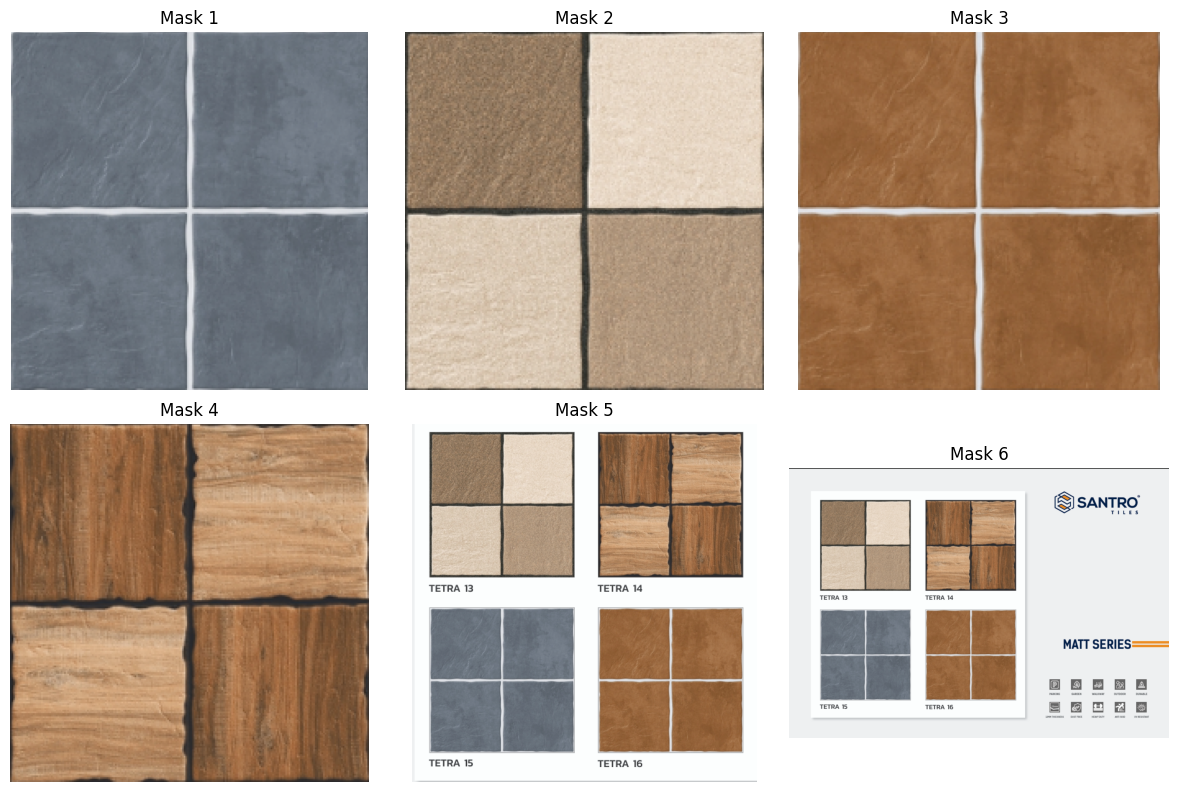

In [40]:
# Plot the cropped images in a grid
num_images = len(cropped_images)
cols = 3
rows = (num_images // cols) + (num_images % cols > 0)

fig, axs = plt.subplots(rows, cols, figsize=(12, 8))

for idx, cropped_image in enumerate(cropped_images):
    ax = axs[idx // cols, idx % cols]
    ax.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(f"Mask {idx + 1}")

# Hide any unused subplots
for idx in range(num_images, rows * cols):
    fig.delaxes(axs[idx // cols, idx % cols])

plt.tight_layout()
plt.show()

In [31]:
import shutil
import os

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"{output_dir} has been deleted.")
else:
    print(f"{output_dir} does not exist.")

In [74]:
import cv2
import supervision as sv
import os
import matplotlib.pyplot as plt
from fastsam import FastSAM

# Initialize FastSAM model
fast_sam_model = FastSAM(FAST_SAM_CHECKPOINT_PATH)  # Adjust if FastSAM requires specific parameters

# Load the image
IMAGE_PATH = '/content/1.png'
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Generate masks using FastSAM
fast_sam_result = fast_sam_model.predict(image_rgb, save=True, save_crop=True)


0: 736x1024 60 objects, 130.6ms
Speed: 4.7ms preprocess, 130.6ms inference, 6.0ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/FastSAM/runs/segment/predict2


In [67]:
fast_sam_result[0].boxes

WARNING ⚠️ 'Boxes.boxes' is deprecated. Use 'Boxes.data' instead.


ultralytics.yolo.engine.results.Boxes object with attributes:

boxes: tensor([[8.0683e+01, 8.2357e+01, 1.8683e+02, 1.8851e+02, 9.7939e-01, 0.0000e+00],
        [1.9087e+02, 1.9269e+02, 2.9747e+02, 2.9926e+02, 9.7418e-01, 0.0000e+00],
        [3.3932e+02, 8.1359e+01, 4.4680e+02, 1.8919e+02, 9.7328e-01, 0.0000e+00],
        [1.9104e+02, 8.2274e+01, 2.9717e+02, 1.8852e+02, 9.7257e-01, 0.0000e+00],
        [8.0438e+01, 1.9268e+02, 1.8668e+02, 2.9895e+02, 9.7008e-01, 0.0000e+00],
        [3.3972e+02, 1.9253e+02, 4.4629e+02, 3.0005e+02, 9.6686e-01, 0.0000e+00],
        [4.5032e+02, 8.1806e+01, 5.5737e+02, 1.8856e+02, 9.6591e-01, 0.0000e+00],
        [3.3896e+02, 3.5087e+02, 5.5907e+02, 5.7104e+02, 9.6583e-01, 0.0000e+00],
        [7.8354e+01, 3.5045e+02, 2.9859e+02, 5.7101e+02, 9.6391e-01, 0.0000e+00],
        [3.3945e+02, 4.6321e+02, 4.4653e+02, 5.7012e+02, 9.6338e-01, 0.0000e+00],
        [4.5154e+02, 4.6319e+02, 5.5859e+02, 5.7004e+02, 9.6298e-01, 0.0000e+00],
        [4.5162e+02, 3.5127e

In [71]:
fast_sam_result[0].masks

WARNING ⚠️ 'Masks.masks' is deprecated. Use 'Masks.data' instead.
WARNING ⚠️ 'Masks.segments' is deprecated. Use 'Masks.xyn' for segments (normalized) and 'Masks.xy' for segments (pixels) instead.


ultralytics.yolo.engine.results.Masks object with attributes:

data: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
        

In [118]:
# Create a directory to save cropped masks (optional)
output_dir = '/content/cropped_masks'
os.makedirs(output_dir, exist_ok=True)

# List to hold cropped images
cropped_images = []
for i, mask_data in enumerate(fast_sam_result[0].masks.xy):
    points = np.int32([mask_data])
    area = cv2.contourArea(points)
    approx = cv2.approxPolyDP(points, 0.02 * cv2.arcLength(points, True), True)
    if area >= 15000 and len(approx) == 4:
    # if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)
        cropped_mask = image_bgr[y:y+h, x:x+w]
        cropped_images.append(cropped_mask)

    cv2.imwrite(f"{output_dir}/mask_{i}.png", cropped_mask)
    print(f"Mask {i} with area {area} saved.")

Mask 0 with area 11881.0 saved.
Mask 1 with area 11440.5 saved.
Mask 2 with area 11808.0 saved.
Mask 3 with area 11429.0 saved.
Mask 4 with area 11869.5 saved.
Mask 5 with area 11842.5 saved.
Mask 6 with area 11506.0 saved.
Mask 7 with area 49437.0 saved.
Mask 8 with area 49471.0 saved.
Mask 9 with area 11863.0 saved.
Mask 10 with area 11638.5 saved.
Mask 11 with area 11611.0 saved.
Mask 12 with area 48295.0 saved.
Mask 13 with area 11864.0 saved.
Mask 14 with area 48605.5 saved.
Mask 15 with area 11722.0 saved.
Mask 16 with area 11830.5 saved.
Mask 17 with area 812.0 saved.
Mask 18 with area 11707.5 saved.
Mask 19 with area 11818.0 saved.
Mask 20 with area 695.5 saved.
Mask 21 with area 812.0 saved.
Mask 22 with area 812.0 saved.
Mask 23 with area 695.5 saved.
Mask 24 with area 792.5 saved.
Mask 25 with area 841.0 saved.
Mask 26 with area 680.0 saved.
Mask 27 with area 11734.5 saved.
Mask 28 with area 693.5 saved.
Mask 29 with area 2063.5 saved.
Mask 30 with area 707.5 saved.
Mask 31 

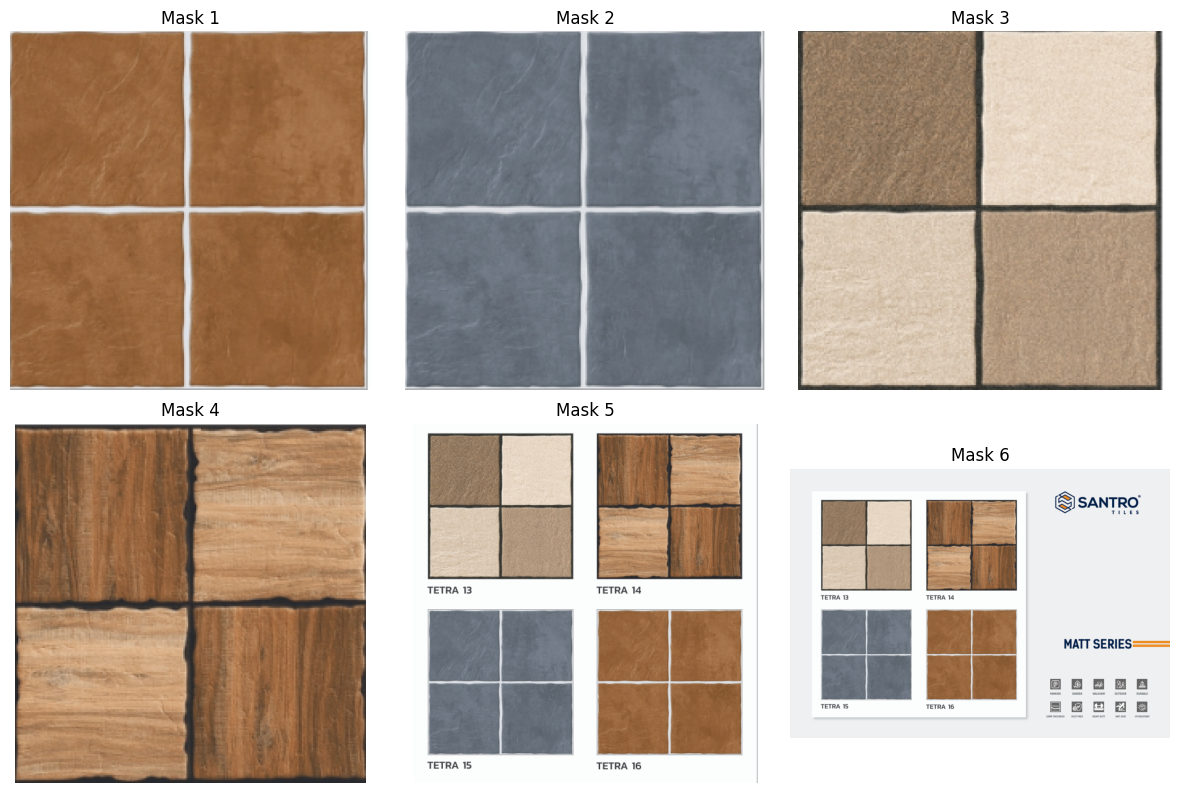

In [119]:
# Plot the cropped images in a grid
num_images = len(cropped_images)
cols = 3
rows = (num_images // cols) + (num_images % cols > 0)

fig, axs = plt.subplots(rows, cols, figsize=(12, 8))

for idx, cropped_image in enumerate(cropped_images):
    ax = axs[idx // cols, idx % cols]
    ax.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(f"Mask {idx + 1}")

# Hide any unused subplots
for idx in range(num_images, rows * cols):
    fig.delaxes(axs[idx // cols, idx % cols])

plt.tight_layout()
plt.show()

In [38]:
import shutil
import os

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"{output_dir} has been deleted.")
else:
    print(f"{output_dir} does not exist.")

/content/cropped_masks has been deleted.
